# Brain Tumor MRI Classification
### Using ResNet50 Transfer Learning

**Student:** Divyansh Yecho &nbsp;&nbsp;&nbsp; **Roll No:** 20231086

This notebook classifies brain MRI scans into 4 categories — **Glioma, Meningioma, No Tumor, and Pituitary Tumor** — using a pretrained ResNet50 CNN fine-tuned via transfer learning.

**Dataset:** Brain Tumor MRI Dataset by Masoud Nickparvar (Kaggle) — 7,200 perfectly balanced MRI images.

---


## 1. Setup & Data Loading


In [1]:
import os

BASE_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/'
TRAIN_DIR = BASE_DIR + 'Training/'
TEST_DIR  = BASE_DIR + 'Testing/'
print('Dataset mounted successfully.')

Dataset mounted successfully.


## 2. Dataset Class Distribution


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

BASE_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/'
TRAIN_DIR = BASE_DIR + 'Training/'
TEST_DIR  = BASE_DIR + 'Testing/'

# Check classes and image counts
print("=== TRAINING SET ===")
classes = sorted([d for d in os.listdir(TRAIN_DIR) 
                  if os.path.isdir(os.path.join(TRAIN_DIR, d))])
total_train = 0
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total_train += count
    print(f"  {cls}: {count} images")
print(f"  Total: {total_train}")

print("\n=== TESTING SET ===")
total_test = 0
for cls in classes:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    total_test += count
    print(f"  {cls}: {count} images")
print(f"  Total: {total_test}")

print(f"\nClasses: {classes}")
print(f"Grand Total: {total_train + total_test} images")

=== TRAINING SET ===
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  Total: 5600

=== TESTING SET ===
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  Total: 1600

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Grand Total: 7200 images


## 3. Dataset Splits — Train / Val / Test


In [3]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

filepaths, labels = [], []
for cls in CLASS_NAMES:
    for fname in os.listdir(os.path.join(TRAIN_DIR, cls)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(TRAIN_DIR, cls, fname))
            labels.append(CLASS_TO_IDX[cls])

train_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

test_fps, test_lbs = [], []
for cls in CLASS_NAMES:
    for fname in os.listdir(os.path.join(TEST_DIR, cls)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_fps.append(os.path.join(TEST_DIR, cls, fname))
            test_lbs.append(CLASS_TO_IDX[cls])

test_df = pd.DataFrame({'filepath': test_fps, 'label': test_lbs})

train_df, val_df = train_test_split(train_df, test_size=0.15, 
                                     stratify=train_df['label'], 
                                     random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Class mapping: {CLASS_TO_IDX}")

Train: 4760 | Val: 840 | Test: 1600
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 4. Transforms & Data Loaders


In [4]:
class BrainTumorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert('RGB')
        label = self.df.iloc[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = BrainTumorDataset(train_df, transform=train_transforms)
val_dataset   = BrainTumorDataset(val_df,   transform=val_transforms)
test_dataset  = BrainTumorDataset(test_df,  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 149 | Val batches: 27 | Test batches: 50


## 5. Model — ResNet50 Transfer Learning


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 4)
)

model = model.to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
print("Ready!")

Using: cuda
Trainable parameters: 525,572
Ready!


## 6. Training


In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

EPOCHS = 25
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

print("Starting training...\n")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = validate_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        saved = "✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} {saved}")

print(f"\nBest Val Accuracy: {best_val_acc:.3f}")

Starting training...

Epoch 01/25 | Train Loss: 0.7818 | Train Acc: 0.685 | Val Loss: 0.6147 | Val Acc: 0.765 ✓ saved
Epoch 02/25 | Train Loss: 0.5355 | Train Acc: 0.799 | Val Loss: 0.4727 | Val Acc: 0.820 ✓ saved
Epoch 03/25 | Train Loss: 0.5251 | Train Acc: 0.801 | Val Loss: 0.4665 | Val Acc: 0.829 ✓ saved
Epoch 04/25 | Train Loss: 0.4665 | Train Acc: 0.829 | Val Loss: 0.3970 | Val Acc: 0.855 ✓ saved
Epoch 05/25 | Train Loss: 0.4687 | Train Acc: 0.824 | Val Loss: 0.3929 | Val Acc: 0.863 ✓ saved
Epoch 06/25 | Train Loss: 0.4259 | Train Acc: 0.839 | Val Loss: 0.4463 | Val Acc: 0.829 
Epoch 07/25 | Train Loss: 0.4246 | Train Acc: 0.837 | Val Loss: 0.3688 | Val Acc: 0.871 ✓ saved
Epoch 08/25 | Train Loss: 0.4179 | Train Acc: 0.838 | Val Loss: 0.3362 | Val Acc: 0.880 ✓ saved
Epoch 09/25 | Train Loss: 0.4275 | Train Acc: 0.837 | Val Loss: 0.3416 | Val Acc: 0.885 ✓ saved
Epoch 10/25 | Train Loss: 0.4249 | Train Acc: 0.844 | Val Loss: 0.3686 | Val Acc: 0.860 
Epoch 11/25 | Train Loss: 0.3940

## 7. Evaluation & Results


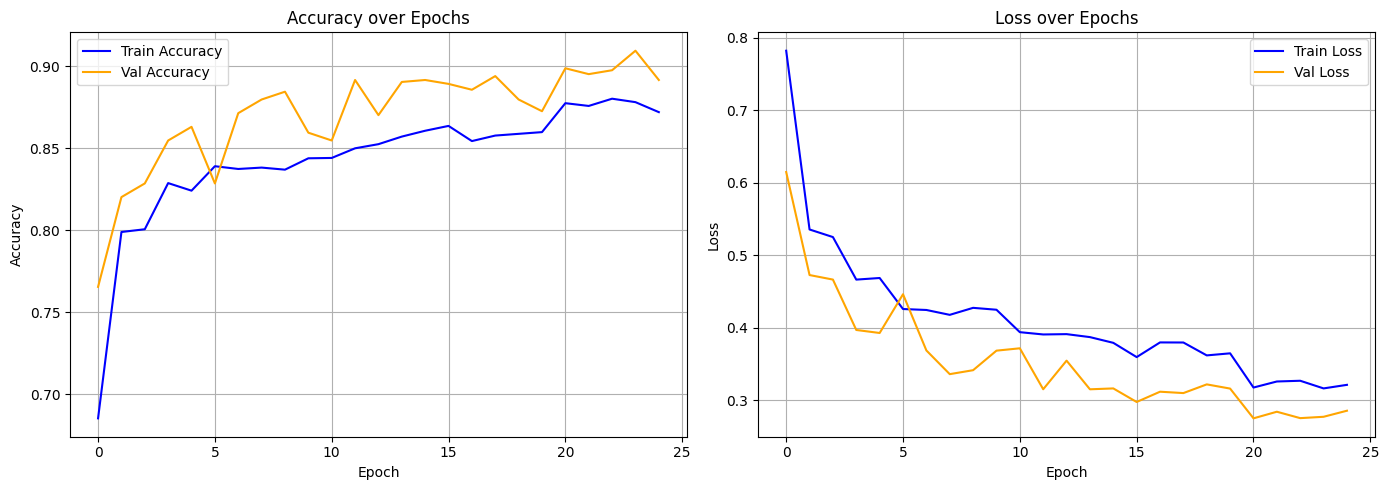

Test Accuracy: 0.846 (84.6%)

              precision    recall  f1-score   support

      glioma       0.90      0.68      0.77       400
  meningioma       0.73      0.81      0.77       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.94      0.91      0.92       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



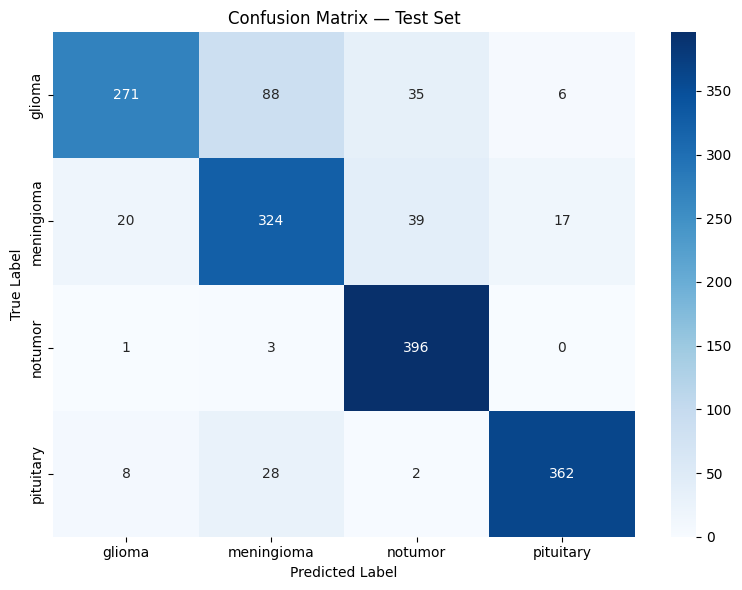

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_accs, label='Train Accuracy', color='blue')
ax1.plot(val_accs, label='Val Accuracy', color='orange')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(train_losses, label='Train Loss', color='blue')
ax2.plot(val_losses, label='Val Loss', color='orange')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds  += outputs.argmax(1).cpu().tolist()
        all_labels += labels.tolist()

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy: {test_acc:.3f} ({test_acc*100:.1f}%)\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Sample Predictions


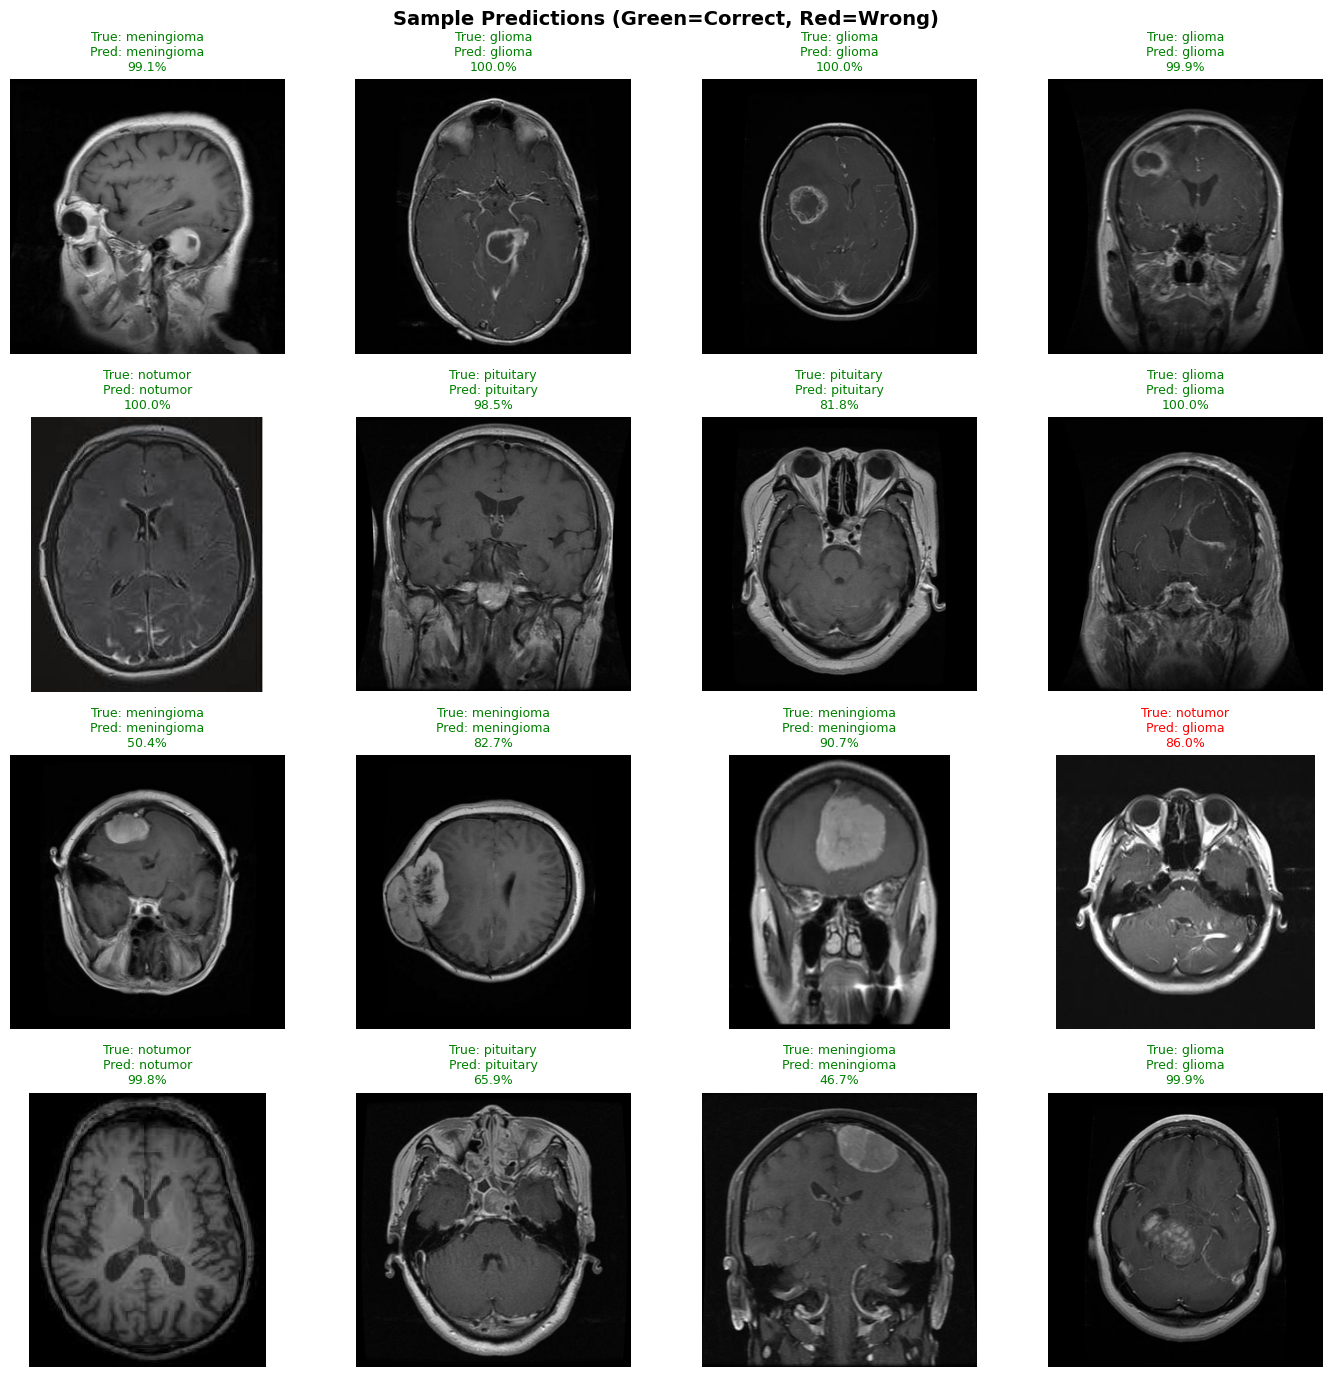

In [8]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

sample = test_df.sample(16, random_state=42).reset_index(drop=True)

for i, row in sample.iterrows():
    img_orig = Image.open(row['filepath']).convert('RGB')
    img_tensor = val_transforms(img_orig).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1).max().item()

    true_label = CLASS_NAMES[row['label']]
    pred_label = CLASS_NAMES[pred]

    axes[i].imshow(img_orig, cmap='gray')
    axes[i].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\n{confidence*100:.1f}%",
                       color=color, fontsize=9)

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

## 9. Per-Class Accuracy


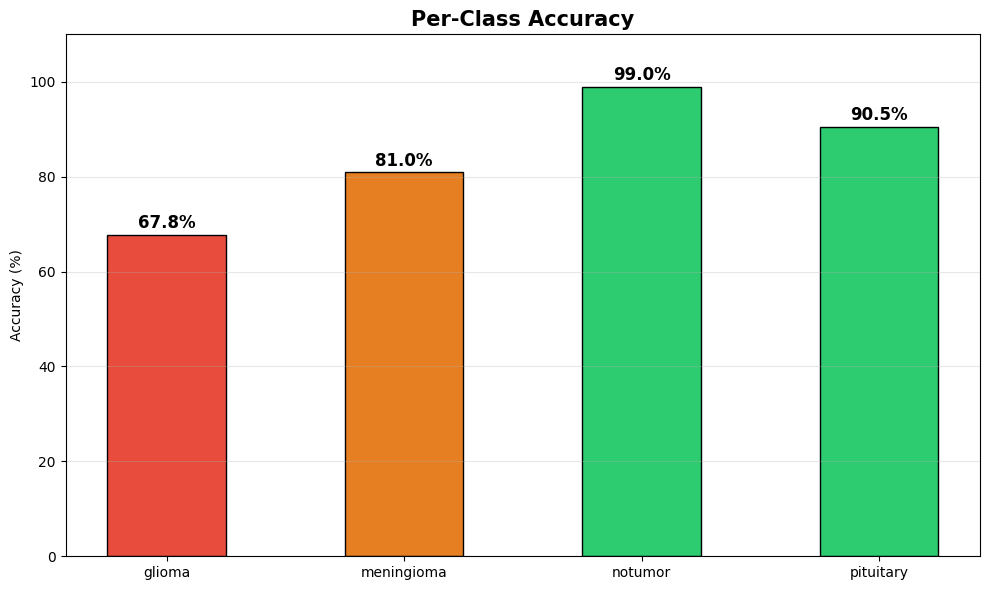

In [9]:
cm = confusion_matrix(all_labels, all_preds)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if acc >= 0.90 else '#e67e22' if acc >= 0.75 else '#e74c3c' 
          for acc in per_class_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Per-Class Accuracy', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()

## 10. Confidence Distribution


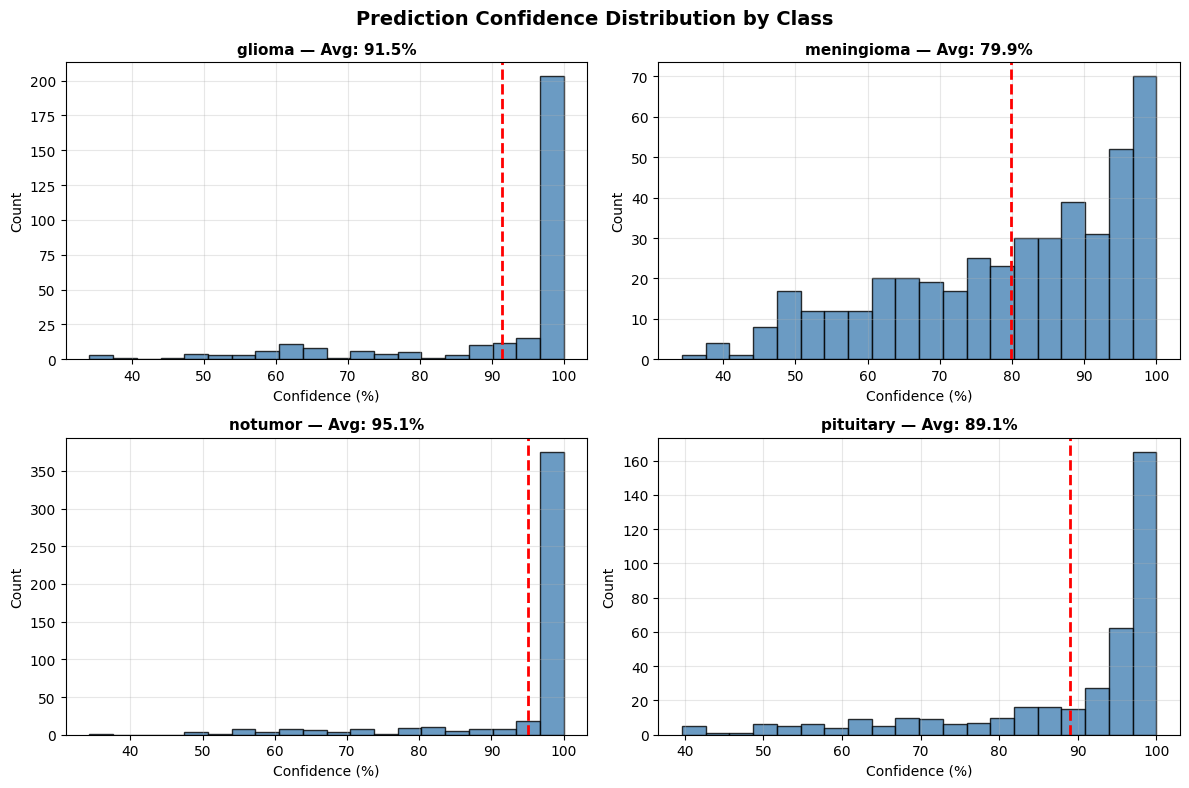

In [10]:
model.eval()
class_confidences = {cls: [] for cls in CLASS_NAMES}

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(1)
        for j in range(len(labels)):
            cls_name = CLASS_NAMES[preds[j].item()]
            class_confidences[cls_name].append(probs[j].max().item() * 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    axes[i].hist(class_confidences[cls], bins=20, color='steelblue', 
                 edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{cls} — Avg: {np.mean(class_confidences[cls]):.1f}%', 
                       fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Confidence (%)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(np.mean(class_confidences[cls]), color='red', 
                    linestyle='--', linewidth=2)
    axes[i].grid(alpha=0.3)

plt.suptitle('Prediction Confidence Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150)
plt.show()

## 11. Probability Breakdown per Class


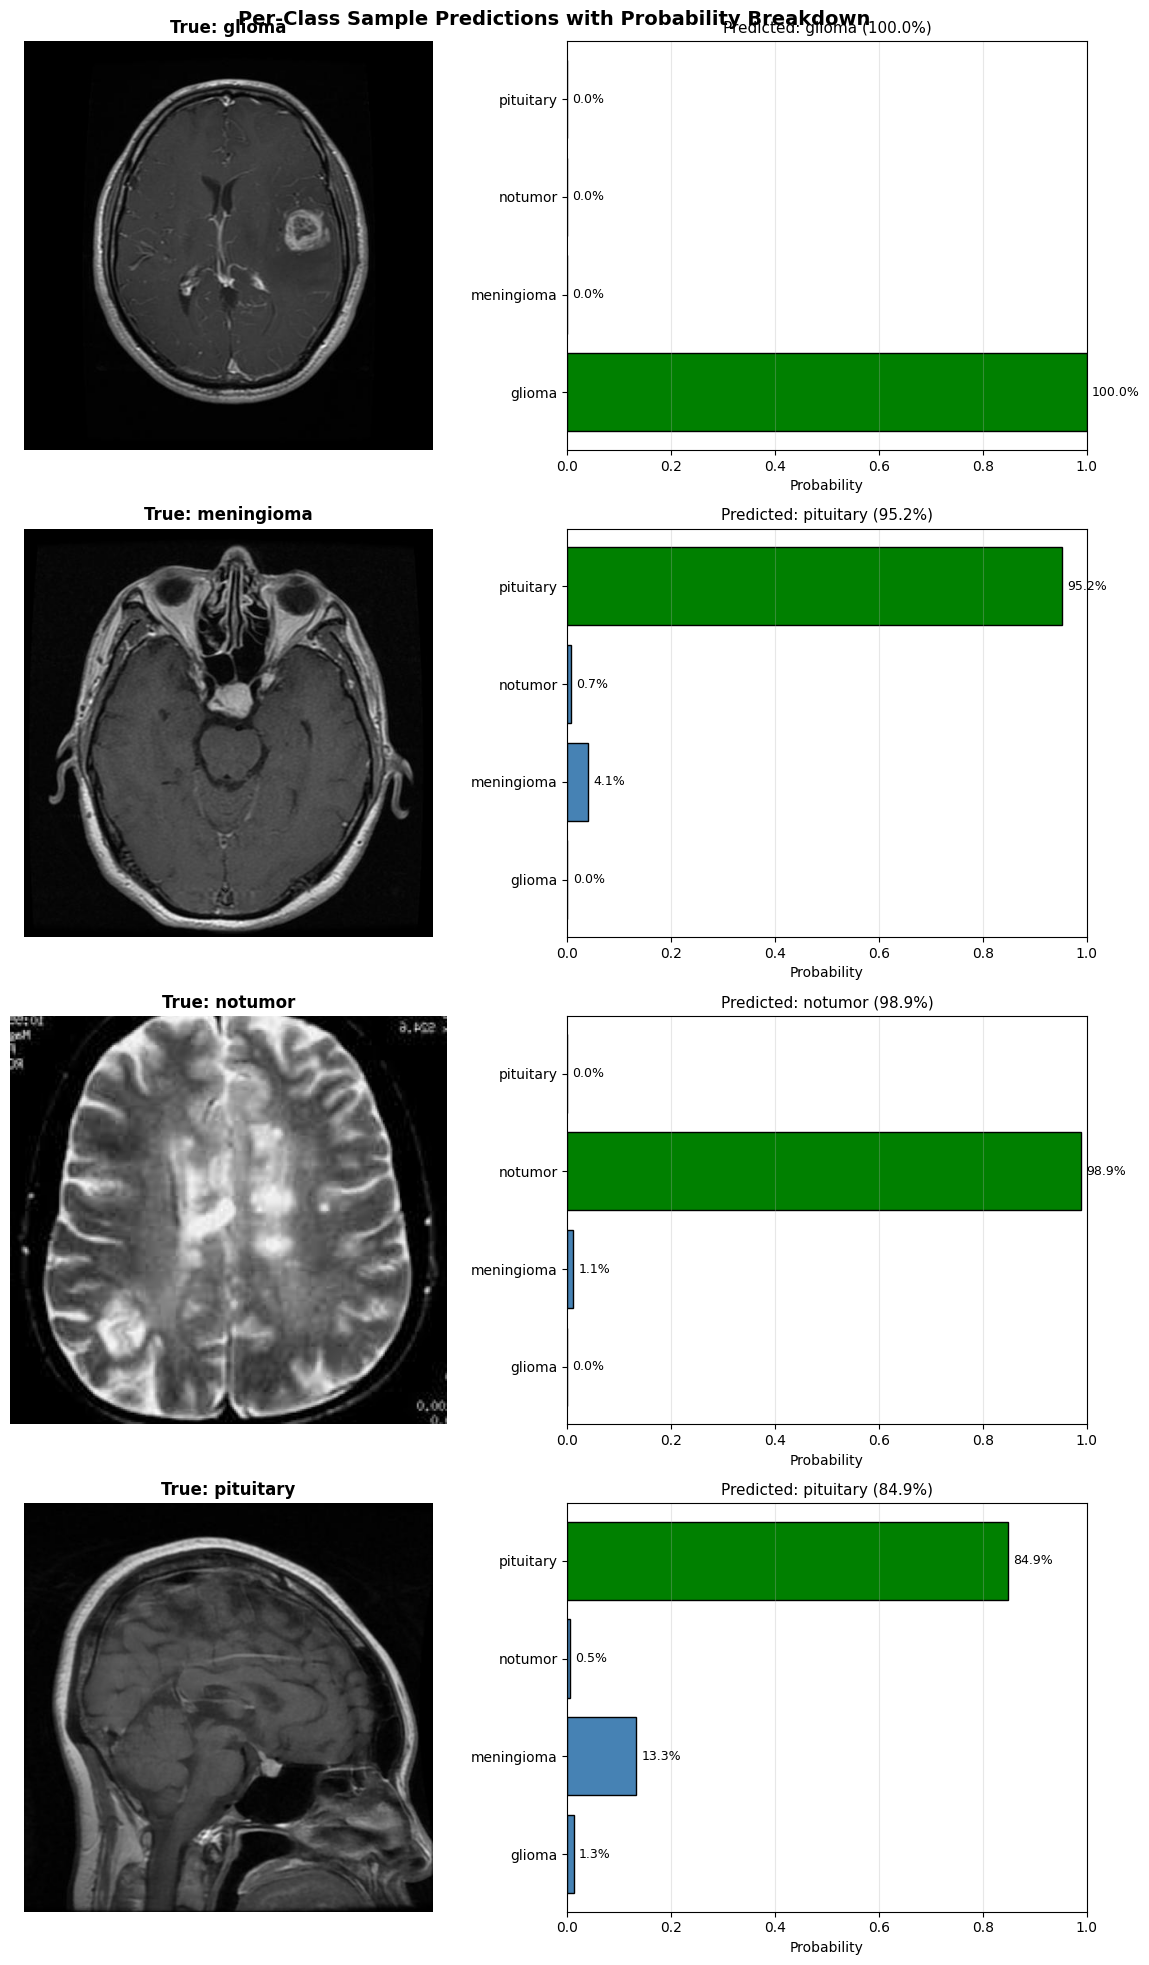

In [11]:
model.eval()
fig, axes = plt.subplots(4, 2, figsize=(12, 20))

for i, cls in enumerate(CLASS_NAMES):
    cls_df = test_df[test_df['label'] == CLASS_TO_IDX[cls]].sample(1, random_state=i)
    img_orig = Image.open(cls_df.iloc[0]['filepath']).convert('RGB')
    img_tensor = val_transforms(img_orig).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()
        pred = probs.argmax()

    axes[i][0].imshow(img_orig, cmap='gray')
    axes[i][0].axis('off')
    axes[i][0].set_title(f'True: {cls}', fontsize=12, fontweight='bold')

    colors = ['green' if j == pred else 'steelblue' for j in range(4)]
    axes[i][1].barh(CLASS_NAMES, probs, color=colors, edgecolor='black')
    axes[i][1].set_xlim(0, 1)
    axes[i][1].set_xlabel('Probability')
    axes[i][1].set_title(f'Predicted: {CLASS_NAMES[pred]} ({probs[pred]*100:.1f}%)', 
                          fontsize=11)
    for j, v in enumerate(probs):
        axes[i][1].text(v + 0.01, j, f'{v*100:.1f}%', va='center', fontsize=9)
    axes[i][1].grid(axis='x', alpha=0.3)

plt.suptitle('Per-Class Sample Predictions with Probability Breakdown', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('probability_breakdown.png', dpi=150)
plt.show()

## 12. Final Summary


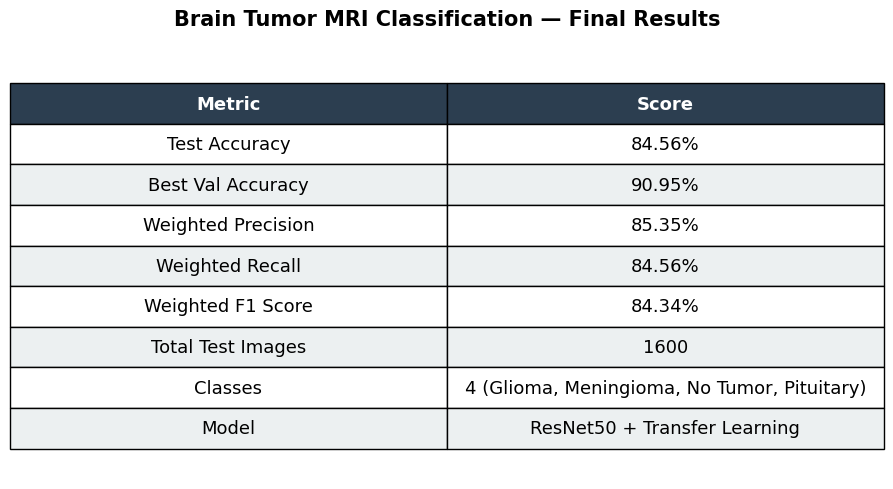


Test Accuracy:      84.56%
Weighted Precision: 85.35%
Weighted Recall:    84.56%
Weighted F1 Score:  84.34%


In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

metrics = [
    ['Metric', 'Score'],
    ['Test Accuracy', f'{test_acc*100:.2f}%'],
    ['Best Val Accuracy', f'{best_val_acc*100:.2f}%'],
    ['Weighted Precision', f'{precision*100:.2f}%'],
    ['Weighted Recall', f'{recall*100:.2f}%'],
    ['Weighted F1 Score', f'{f1*100:.2f}%'],
    ['Total Test Images', '1600'],
    ['Classes', '4 (Glioma, Meningioma, No Tumor, Pituitary)'],
    ['Model', 'ResNet50 + Transfer Learning'],
]

table = ax.table(cellText=metrics[1:], colLabels=metrics[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.5, 2.2)

for j in range(2):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(metrics)):
    for j in range(2):
        table[i, j].set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')

plt.title('Brain Tumor MRI Classification — Final Results', 
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('final_summary.png', dpi=150)
plt.show()

print(f"\nTest Accuracy:      {test_acc*100:.2f}%")
print(f"Weighted Precision: {precision*100:.2f}%")
print(f"Weighted Recall:    {recall*100:.2f}%")
print(f"Weighted F1 Score:  {f1*100:.2f}%")